**Name:** Ganesh Dahiphale

**Roll no.:** 23102B0057

In [1]:
import pandas as pd

column_names = [
    'class', 'alcohol', 'malic_acid', 'ash', 'alcalinity_of_ash',
    'magnesium', 'total_phenols', 'flavanoids', 'nonflavanoid_phenols',
    'proanthocyanins', 'color_intensity', 'hue', 'od280_od315_of_diluted_wines',
    'proline'
]

wine_df = pd.read_csv('/content/wine.data', header=None, names=column_names)

print("Wine DataFrame head:")
display(wine_df.head())

print("\nWine DataFrame info:")
wine_df.info()

Wine DataFrame head:


,class,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,1,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,1,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,1,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,1,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Wine DataFrame info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   class                         178 non-null    int64  
 1   alcohol                       178 non-null    float64
 2   malic_acid                    178 non-null    float64
 3   ash                           178 non-null    float64
 4   alcalinity_of_ash             178 non-null    float64
 5   magnesium                     178 non-null    int64  
 6   total_phenols                 178 non-null    float64
 7   flavanoids                    178 non-null    float64
 8   nonflavanoid_phenols          178 non-null    float64
 9   proanthocyanins               178 non-null    float64
 10  color_intensity               178 non-null    float64
 11  hue                           178 non-null    float64
 12  od280_od315_of_diluted_wines  178 non-null

In [2]:

X = wine_df.drop('class', axis=1)
y = wine_df['class']

print("\nFeatures (X) head:")
display(X.head())

print("\nTarget (y) head:")
display(y.head())


Features (X) head:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065
1,13.20,1.78,2.14,11.2,100,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050
2,13.16,2.36,2.67,18.6,101,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185
3,14.37,1.95,2.50,16.8,113,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480
4,13.24,2.59,2.87,21.0,118,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735



Target (y) head:


,class
0,1
1,1
2,1
3,1
4,1


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("\nScaled Features (X_scaled) head:")
display(pd.DataFrame(X_scaled, columns=X.columns).head())


Scaled Features (X_scaled) head:


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280_od315_of_diluted_wines,proline
0,1.518613,-0.562250,0.232053,-1.169593,1.913905,0.808997,1.034819,-0.659563,1.224884,0.251717,0.362177,1.847920,1.013009
1,0.246290,-0.499413,-0.827996,-2.490847,0.018145,0.568648,0.733629,-0.820719,-0.544721,-0.293321,0.406051,1.113449,0.965242
2,0.196879,0.021231,1.109334,-0.268738,0.088358,0.808997,1.215533,-0.498407,2.135968,0.269020,0.318304,0.788587,1.395148
3,1.691550,-0.346811,0.487926,-0.809251,0.930918,2.491446,1.466525,-0.981875,1.032155,1.186068,-0.427544,1.184071,2.334574
4,0.295700,0.227694,1.840403,0.451946,1.281985,0.808997,0.663351,0.226796,0.401404,-0.319276,0.362177,0.449601,-0.037874



LDA 2D Projection DataFrame head:


,SampleId,LD1,LD2,Class
0,1,-4.700244,1.979138,1
1,2,-4.301958,1.170413,1
2,3,-3.420720,1.429101,1
3,4,-4.205754,4.002871,1
4,5,-1.509982,0.451224,1


2D LDA projection saved to lda_projection.csv


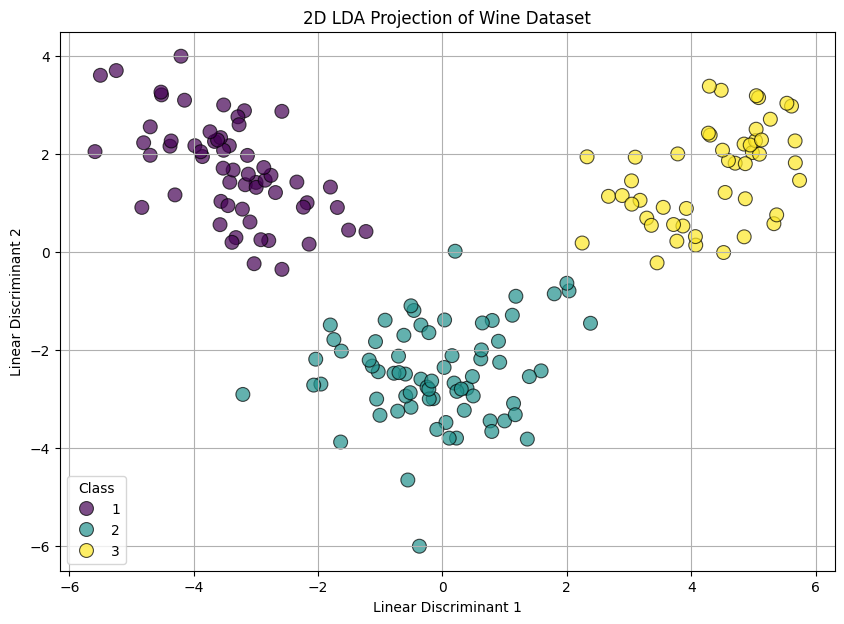

In [5]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

lda = LinearDiscriminantAnalysis(n_components=2)
X_lda_2d = lda.fit_transform(X_scaled, y)

lda_df_2d = pd.DataFrame(
    data=X_lda_2d,
    columns=['LD1', 'LD2']
)
lda_df_2d['Class'] = y

lda_df_2d.insert(0, 'SampleId', lda_df_2d.index + 1)

print("\nLDA 2D Projection DataFrame head:")
display(lda_df_2d.head())

lda_df_2d.to_csv('lda_projection.csv', index=False)
print("2D LDA projection saved to lda_projection.csv")

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='LD1', y='LD2', hue='Class', data=lda_df_2d,
    palette='viridis', s=100, alpha=0.7,
    edgecolor='k', legend='full'
)
plt.title('2D LDA Projection of Wine Dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Linear Discriminant 2')
plt.grid(True)
plt.show()

In [6]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

X_train_orig, X_test_orig, y_train_orig, y_test_orig = train_test_split(
X_scaled, y, test_size=0.3, random_state=42, stratify=y
)

log_reg_orig = LogisticRegression(max_iter=1000, random_state=42)
log_reg_orig.fit(X_train_orig, y_train_orig)
y_pred_orig = log_reg_orig.predict(X_test_orig)

accuracy_orig = accuracy_score(y_test_orig, y_pred_orig)
f1_orig = f1_score(y_test_orig, y_pred_orig, average='weighted')

print(f"\nPerformance on Original Scaled Data:\nAccuracy: {accuracy_orig:.4f}\nF1-score: {f1_orig:.4f}")


Performance on Original Scaled Data:
Accuracy: 0.9815
F1-score: 0.9815


In [7]:

X_train_lda, X_test_lda, y_train_lda, y_test_lda = train_test_split(
X_lda_2d, y, test_size=0.3, random_state=42, stratify=y
)

log_reg_lda = LogisticRegression(max_iter=1000, random_state=42)
log_reg_lda.fit(X_train_lda, y_train_lda)
y_pred_lda = log_reg_lda.predict(X_test_lda)

accuracy_lda = accuracy_score(y_test_lda, y_pred_lda)
f1_lda = f1_score(y_test_lda, y_pred_lda, average='weighted')

print(f"\nPerformance on 2D LDA-Reduced Data:\nAccuracy: {accuracy_lda:.4f}\nF1-score: {f1_lda:.4f}")

print("\n--- Classification Performance Comparison ---")
print(f"Original Data - Accuracy: {accuracy_orig:.4f}, F1-score: {f1_orig:.4f}")
print(f"LDA Reduced Data - Accuracy: {accuracy_lda:.4f}, F1-score: {f1_lda:.4f}")


Performance on 2D LDA-Reduced Data:
Accuracy: 1.0000
F1-score: 1.0000

--- Classification Performance Comparison ---
Original Data - Accuracy: 0.9815, F1-score: 0.9815
LDA Reduced Data - Accuracy: 1.0000, F1-score: 1.0000



LDA 1D Projection DataFrame head:


,LD1,Class
0,-4.700244,1
1,-4.301958,1
2,-3.420720,1
3,-4.205754,1
4,-1.509982,1


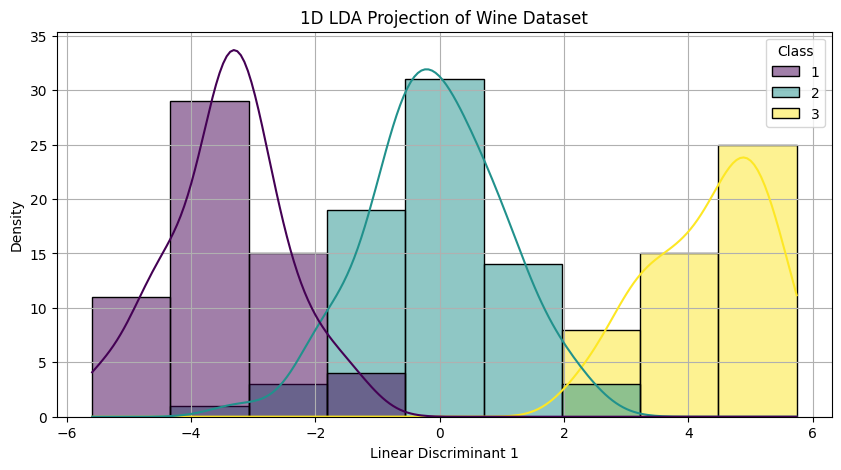

In [8]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

lda_1d = LinearDiscriminantAnalysis(n_components=1)
X_lda_1d = lda_1d.fit_transform(X_scaled, y)

lda_df_1d = pd.DataFrame(
    data=X_lda_1d,
    columns=['LD1']
)
lda_df_1d['Class'] = y

print("\nLDA 1D Projection DataFrame head:")
display(lda_df_1d.head())

plt.figure(figsize=(10, 5))
sns.histplot(data=lda_df_1d, x='LD1', hue='Class', kde=True, palette='viridis')
plt.title('1D LDA Projection of Wine Dataset')
plt.xlabel('Linear Discriminant 1')
plt.ylabel('Density')
plt.grid(True)
plt.show()

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, f1_score

X_train_lda_1d, X_test_lda_1d, y_train_lda_1d, y_test_lda_1d = train_test_split(
X_lda_1d, y, test_size=0.3, random_state=42, stratify=y
)

log_reg_lda_1d = LogisticRegression(max_iter=1000, random_state=42)
log_reg_lda_1d.fit(X_train_lda_1d, y_train_lda_1d)
y_pred_lda_1d = log_reg_lda_1d.predict(X_test_lda_1d)

accuracy_lda_1d = accuracy_score(y_test_lda_1d, y_pred_lda_1d)
f1_lda_1d = f1_score(y_test_lda_1d, y_pred_lda_1d, average='weighted')

print(f"\nPerformance on 1D LDA-Reduced Data:\nAccuracy: {accuracy_lda_1d:.4f}\nF1-score: {f1_lda_1d:.4f}")

print("\n--- Final Classification Performance Comparison ---")
print(f"Original Data - Accuracy: {accuracy_orig:.4f}, F1-score: {f1_orig:.4f}")
print(f"2D LDA Reduced Data - Accuracy: {accuracy_lda:.4f}, F1-score: {f1_lda:.4f}")
print(f"1D LDA Reduced Data - Accuracy: {accuracy_lda_1d:.4f}, F1-score: {f1_lda_1d:.4f}")


Performance on 1D LDA-Reduced Data:
Accuracy: 0.9074
F1-score: 0.9079

--- Final Classification Performance Comparison ---
Original Data - Accuracy: 0.9815, F1-score: 0.9815
2D LDA Reduced Data - Accuracy: 1.0000, F1-score: 1.0000
1D LDA Reduced Data - Accuracy: 0.9074, F1-score: 0.9079


## Why LDA differs from PCA

LDA (Linear Discriminant Analysis) is a supervised dimensionality reduction technique, meaning it considers the class labels to find a projection that maximizes class separability. In contrast, PCA (Principal Component Analysis) is an unsupervised technique that finds directions of maximum variance in the data without considering class information. This fundamental difference makes LDA particularly effective for classification tasks where distinguishing between classes is paramount.

## Short Report on LDA Performance

**Class Separability After Projection:** The 2D LDA projection clearly showed excellent separation between the three wine classes, forming distinct, well-separated clusters. The 1D LDA projection also demonstrated good separation with discernible peaks for each class, indicating that LDA effectively found dimensions that maximize inter-class variance while minimizing intra-class variance.

**Impact on Classification Performance:**
*   **Original Scaled Data:** Accuracy: 0.9815, F1-score: 0.9815
*   **2D LDA Reduced Data:** Accuracy: 1.0000, F1-score: 1.0000
*   **1D LDA Reduced Data:** Accuracy: 0.9074, F1-score: 0.9079

Reducing dimensionality with LDA significantly improved classification performance. The 2D LDA achieved perfect accuracy, outperforming both the original scaled data and the 1D LDA. This highlights LDA's strength in creating highly discriminative features for classification tasks.